In [1]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [13]:
base_folder = '../data/originals'

In [14]:
classes = [d for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))]
print("Audio classes found:", classes)

Audio classes found: ['aggression', 'alarm_siren', 'animal_sound', 'background_noise', 'glass_breaking', 'gunshot', 'machinery_fault', 'panic_scream', 'vehicle_horn']


In [15]:
file_counts = {}
for audio_class in classes:
    class_path = os.path.join(base_folder, audio_class)
    files = os.listdir(class_path)
    file_counts[audio_class] = len(files)

print("\nFiles per category:")
for category, count in file_counts.items():
    print(f"{category}: {count}")


Files per category:
aggression: 300
alarm_siren: 301
animal_sound: 300
background_noise: 300
glass_breaking: 300
gunshot: 300
machinery_fault: 300
panic_scream: 300
vehicle_horn: 300


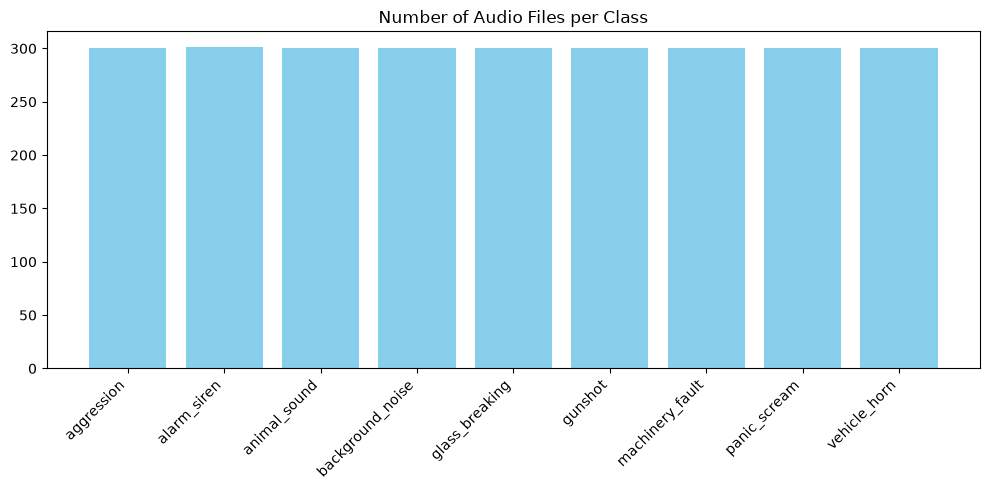

In [16]:
plt.figure(figsize=(10, 5))
plt.bar(file_counts.keys(), file_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Audio Files per Class")
plt.tight_layout()
plt.show()

In [17]:
first_class = classes[0]
first_class_dir = os.path.join(base_folder, first_class)
first_audio_name = os.listdir(first_class_dir)[0]
test_audio_path = os.path.join(first_class_dir, first_audio_name)

print(f"\nTesting audio load on: {test_audio_path}")


Testing audio load on: ../data/originals\aggression\aggression_0001.wav


In [18]:
y, sr = librosa.load(test_audio_path, sr=None)
audio_duration = librosa.get_duration(y=y, sr=sr)

Exception ignored in: <function ObjectRef.__del__ at 0x000001619884D800>
Traceback (most recent call last):
  File "d:\ANACONDA\envs\sonic\Lib\site-packages\llvmlite\binding\ffi.py", line 395, in __del__
    self.close()
  File "d:\ANACONDA\envs\sonic\Lib\site-packages\llvmlite\binding\ffi.py", line 355, in close
    self._dispose()
  File "d:\ANACONDA\envs\sonic\Lib\site-packages\llvmlite\binding\module.py", line 249, in _dispose
    self._capi.LLVMPY_DisposeFunctionsIter(self)
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\envs\sonic\Lib\site-packages\llvmlite\binding\ffi.py", line 153, in __getattr__
    def __getattr__(self, name):

KeyboardInterrupt: 


In [19]:
print(f"Sample rate: {sr} Hz")
print(f"Duration: {audio_duration:.2f} seconds")

Sample rate: 16000 Hz
Duration: 3.00 seconds


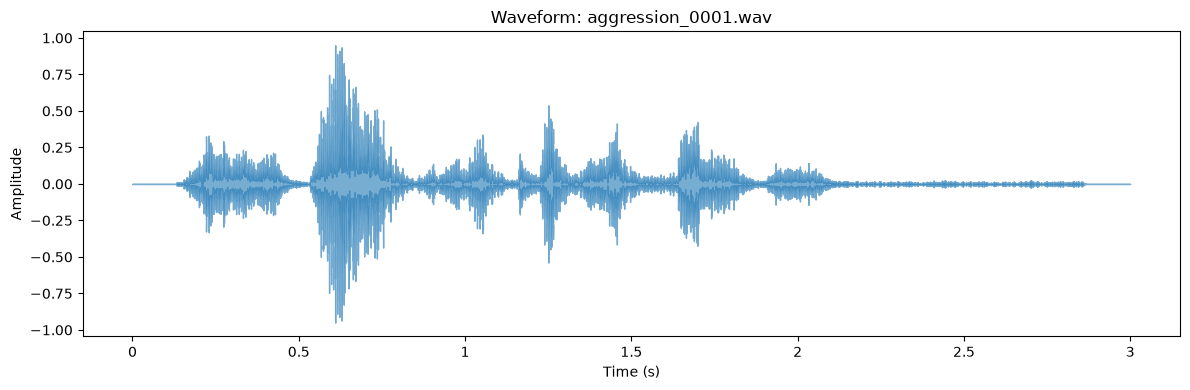

In [20]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.6)
plt.title(f"Waveform: {first_audio_name}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [21]:
plt.figure(figsize=(12, 4))
melspec = librosa.feature.melspectrogram(y=y, sr=sr)
melspec_db = librosa.power_to_db(melspec, ref=np.max)

<Figure size 1200x400 with 0 Axes>

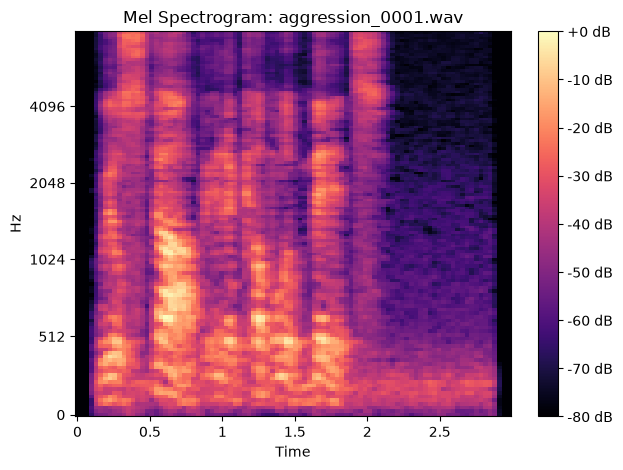

In [22]:
librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram: {first_audio_name}")
plt.tight_layout()
plt.show()

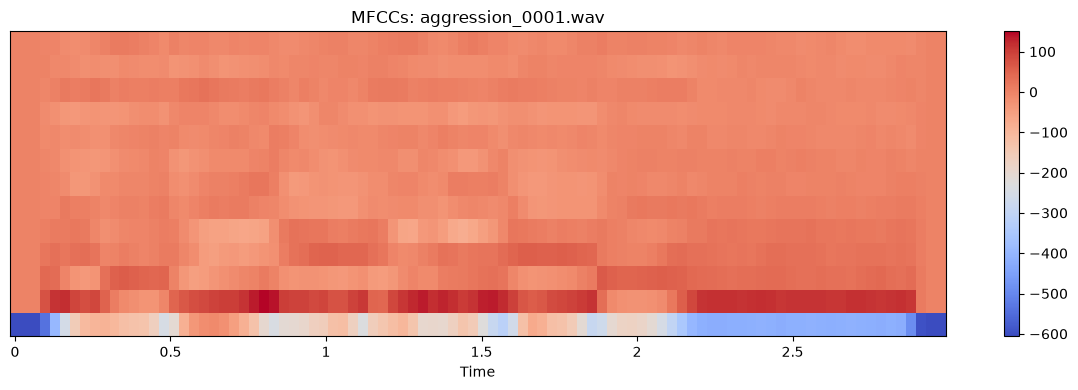

In [23]:
plt.figure(figsize=(12, 4))
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title(f"MFCCs: {first_audio_name}")
plt.tight_layout()
plt.show()

In [24]:
zcr = librosa.feature.zero_crossing_rate(y)[0]
frames = range(len(zcr))
t = librosa.frames_to_time(frames, sr=sr)

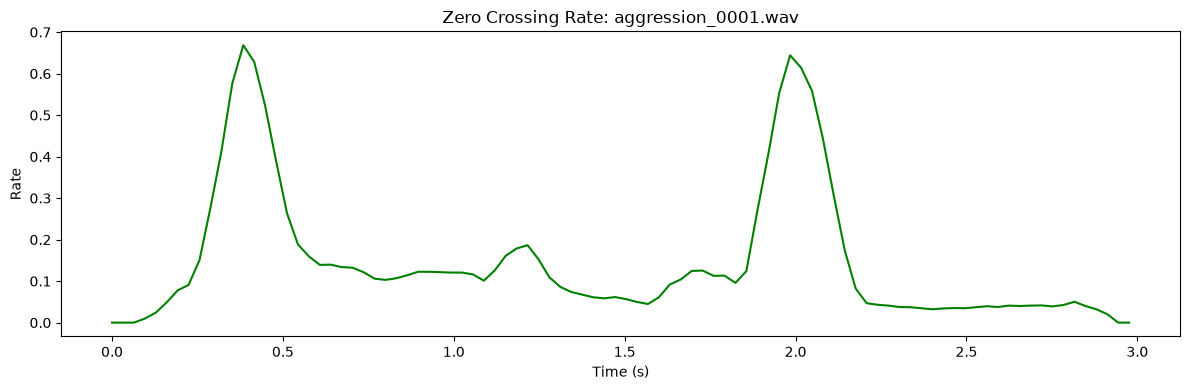

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(t, zcr, color='green')
plt.title(f"Zero Crossing Rate: {first_audio_name}")
plt.xlabel("Time (s)")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()